# Plot all SDS waveform data for a rocket launch

Small utility to load **all available seismic and infrasound data** from an ObsPy SDS archive for a user-supplied time window and plot every returned trace.

Edit the configuration cell below, then run the notebook top-to-bottom.


In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
from obspy import UTCDateTime
from obspy.clients.filesystem.sds import Client

# -------------------------
# USER CONFIGURATION
# -------------------------

# Root directory of the SDS archive
SDS_ROOT = Path('/Volumes/KSCGTdownld/Paul_service') # goes up to day 163 = June 12
SDS_ROOT = Path('~/Downloads').expanduser()

# Supply the rocket-launch plotting interval here.
# UTCDateTime accepts ISO strings, e.g. '2026-09-23T12:34:00'.
STARTTIME = UTCDateTime('2026-06-08T10:10:00')
ENDTIME   = UTCDateTime('2026-06-08T10:20:00')
STARTTIME = UTCDateTime('2026-06-04T10:23:00')
ENDTIME   = UTCDateTime('2026-06-04T10:30:00')
STARTTIME = UTCDateTime('2026-08-30T11:23:00')
ENDTIME   = UTCDateTime('2026-08-30T11:30:00')

# By default, request everything in the archive.
# These can be narrowed later if useful.
NETWORK  = '*'
STATION  = '*'
LOCATION = '*'
CHANNEL  = '*'


In [14]:
# Create the SDS client and request all matching waveform data.
client = Client(str(SDS_ROOT))

st = client.get_waveforms(
    NETWORK,
    STATION,
    LOCATION,
    CHANNEL,
    STARTTIME,
    ENDTIME,
)

print(f'Returned {len(st)} trace segment(s) before merge.')

# Sort for predictable station/channel ordering.
st.sort(keys=['network', 'station', 'location', 'channel', 'starttime'])

# Merge contiguous/overlapping segments belonging to the same trace ID.
# method=1 interpolates only across overlaps; true gaps remain masked.
st.merge(method=1, fill_value=None)

# Trim exactly to the requested launch window.
st.trim(STARTTIME, ENDTIME)

print(f'{len(st)} trace(s) after merge.')
for tr in st:
    print(tr.id, tr.stats.starttime, tr.stats.endtime, tr.stats.npts)


Returned 24 trace segment(s) before merge.
24 trace(s) after merge.
1R.B20.00.DD1 2026-08-30T11:23:00.000000Z 2026-08-30T11:30:00.000000Z 210001
1R.B20.00.DD2 2026-08-30T11:23:00.000000Z 2026-08-30T11:30:00.000000Z 210001
1R.B20.00.DDF 2026-08-30T11:23:00.000000Z 2026-08-30T11:30:00.000000Z 210001
1R.B20.00.DH1 2026-08-30T11:23:00.000000Z 2026-08-30T11:30:00.000000Z 210001
1R.B20.00.DH2 2026-08-30T11:23:00.000000Z 2026-08-30T11:30:00.000000Z 210001
1R.B20.00.DHZ 2026-08-30T11:23:00.000000Z 2026-08-30T11:30:00.000000Z 210001
1R.B20.00.LD1 2026-08-30T11:23:00.000000Z 2026-08-30T11:30:00.000000Z 421
1R.B20.00.LD2 2026-08-30T11:23:00.000000Z 2026-08-30T11:30:00.000000Z 421
1R.B20.00.LDF 2026-08-30T11:23:00.000000Z 2026-08-30T11:30:00.000000Z 421
1R.B20.00.LH1 2026-08-30T11:23:00.000000Z 2026-08-30T11:30:00.000000Z 421
1R.B20.00.LH2 2026-08-30T11:23:00.000000Z 2026-08-30T11:30:00.000000Z 421
1R.B20.00.LHZ 2026-08-30T11:23:00.000000Z 2026-08-30T11:30:00.000000Z 421
1R.B24.00.DD0 2026-08-30T1

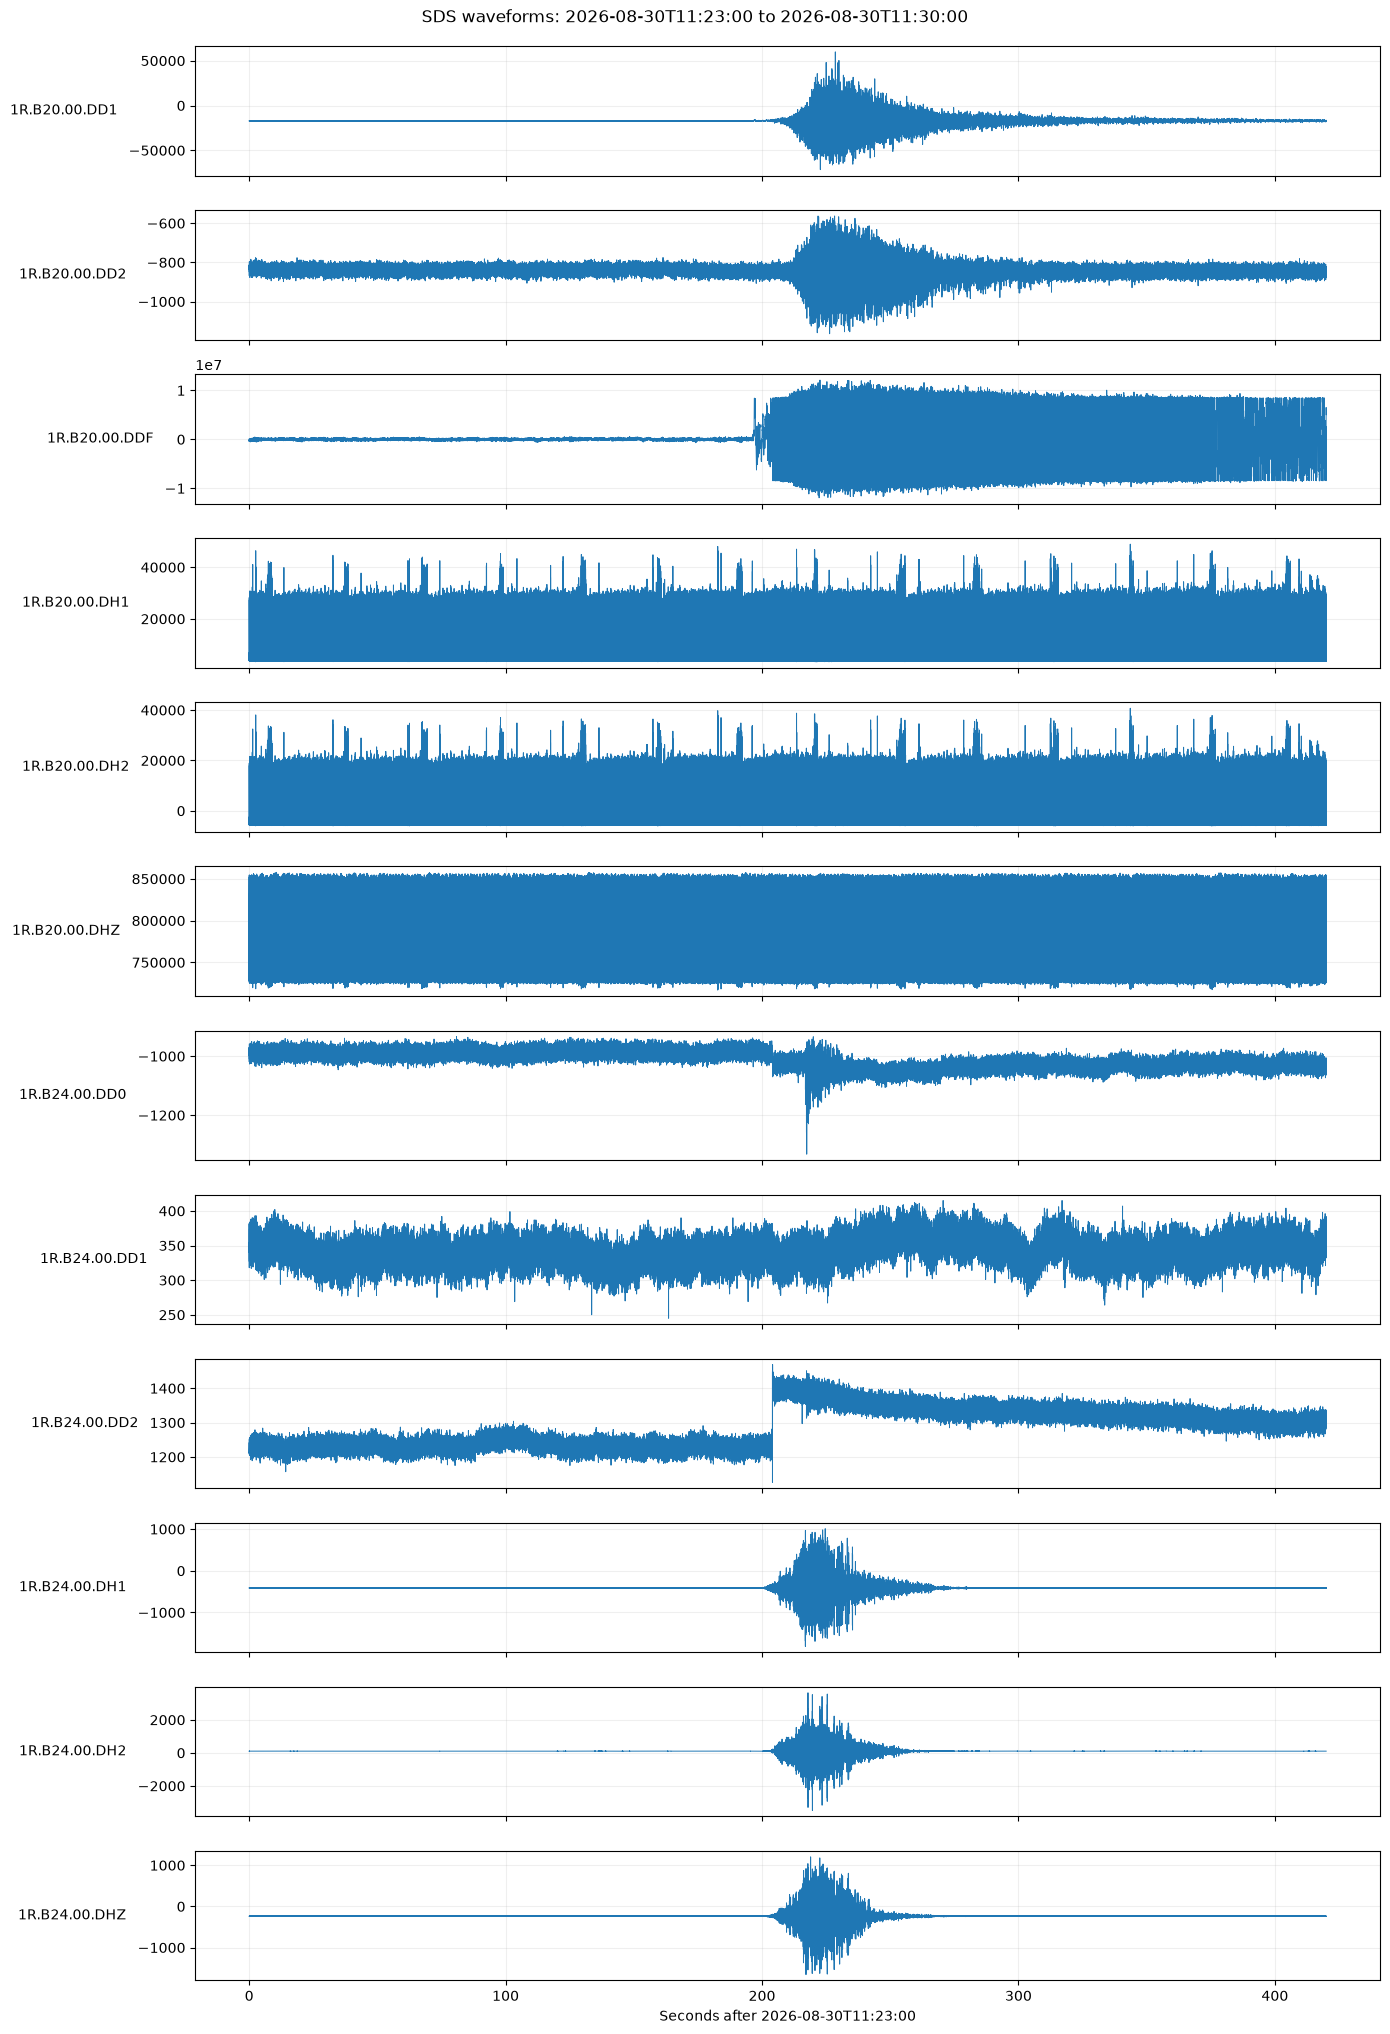

In [15]:
st = st.select(channel='D*')
if len(st) == 0:
    print('No waveform data found for the requested time interval.')
else:
    ntr = len(st)
    fig_height = max(4, 1.7 * ntr)
    fig, axes = plt.subplots(
        ntr,
        1,
        figsize=(14, fig_height),
        sharex=True,
        squeeze=False,
    )
    axes = axes[:, 0]

    for ax, tr in zip(axes, st):
        # Relative time from requested STARTTIME, in seconds.
        t = tr.times(reftime=STARTTIME)
        ax.plot(t, tr.data, linewidth=0.7)

        loc = tr.stats.location if tr.stats.location else '--'
        label = f'{tr.stats.network}.{tr.stats.station}.{loc}.{tr.stats.channel}'
        ax.set_ylabel(label, rotation=0, ha='right', va='center', labelpad=8)
        ax.grid(True, alpha=0.2)

    axes[-1].set_xlabel(f'Seconds after {STARTTIME.isoformat()}')
    fig.suptitle(
        f'SDS waveforms: {STARTTIME.isoformat()} to {ENDTIME.isoformat()}',
        y=0.995,
    )
    fig.tight_layout()
    plt.show()


## Notes

- `Client.get_waveforms('*', '*', '*', '*', ...)` asks the SDS archive for all available network, station, location, and channel codes in the requested interval.
- No seismic/infrasound channel naming assumptions are made, so channels such as `HH?`, `BH?`, `EH?`, `HD?`, `HDF`, etc. are all included if present.
- Genuine data gaps remain masked rather than being filled with zeros.
- For long time windows or very large networks, narrow the wildcard selectors in the configuration cell if needed.


Yes. I filtered to **actual launches from Kennedy Space Center and Cape Canaveral SFS from May 1, 2026 through today, September 23, 2026**, excluding Vandenberg and excluding scrubs/static-fire tests. I’ve put the times in **UTC**, since that is what you’ll want for `UTCDateTime` and the SDS archive. The sequence is supported particularly well by the SLC-40 launch history, ULA/Atlas history, LC-39A history, and current Space Coast launch logs. :chatgpt-content-reference{index="0"}

| UTC launch time | Mission | Rocket | Pad |
|---|---|---|---|
| **2026-05-01 18:06** | Starlink 10-38 | Falcon 9 | SLC-40 |
| **2026-05-15 22:05** | SpaceX CRS-34 | Falcon 9 | SLC-40 |
| **2026-05-21 10:04** | Starlink 10-31 | Falcon 9 | SLC-40 |
| **2026-05-25 11:48** | Starlink 10-47 | Falcon 9 | SLC-40 |
| **2026-05-29 12:57** | Starlink 10-53 | Falcon 9 | SLC-40 |
| **2026-05-29 23:53** | Amazon Leo LA-07 | Atlas V 551 | SLC-41 |
| **2026-06-04 10:26** | Starlink 10-43 | Falcon 9 | SLC-40 |
| **2026-06-08 10:13** | Starlink 10-35 | Falcon 9 | SLC-40 |
| **2026-06-12 12:37** | Starlink 10-54 | Falcon 9 | SLC-40 |
| **2026-06-17 06:39** | BlueBird 8–10 | Falcon 9 | SLC-40 |
| **2026-06-23 10:53** | Starfall Demo | Falcon 9 | SLC-40 |
| **2026-06-29 02:25** | SXM-11 | Falcon 9 | SLC-40 |
| **2026-07-02 04:30** | Amazon Leo LA-08 | Atlas V 551 | SLC-41 |
| **2026-07-05 10:50** | Starlink 10-50 | Falcon 9 | SLC-40 |
| **2026-07-09 09:25** | Starlink 10-42 | Falcon 9 | SLC-40 |
| **2026-07-14 09:10** | Starlink 10-45 | Falcon 9 | SLC-40 |
| **2026-07-21 21:15** | MRV-1 / Mission Robotic Vehicle | Falcon 9 | SLC-40 |
| **2026-07-30 07:10** | NROL-95 | Falcon 9 | SLC-40 |
| **2026-08-05 07:49** | BlueBird 11–13 | Falcon 9 | SLC-40 |
| **2026-08-11 15:58** | Starlink 10-19 | Falcon 9 | SLC-40 |
| **2026-08-16 01:12** | Globalstar-2R | Falcon 9 | SLC-40 |
| **2026-08-21 15:14** | Starlink 10-39 | Falcon 9 | SLC-40 |
| **2026-08-25 09:33** | Starlink 10-49 | Falcon 9 | SLC-40 |
| **2026-08-30 11:26** | Nancy Grace Roman Space Telescope | **Falcon Heavy** | **LC-39A, KSC** |
| **2026-09-13 18:49** | O3b mPOWER 11–13 | Falcon 9 | SLC-40 |

The May–August SLC-40 sequence is independently tabulated in the pad launch history. :chatgpt-content-reference{index="1"} The two Atlas V launches were **May 29 at 23:53 UTC** and **July 2 at 04:30 UTC** from SLC-41. :chatgpt-content-reference{index="2"} The only KSC launch in this interval appears to be the **August 30 Falcon Heavy / Roman Space Telescope launch at 11:26 UTC from LC-39A**; LC-39A had otherwise been taken out of routine Falcon 9 service. :chatgpt-content-reference{index="3"} The latest completed Florida launch I find as of September 23 is **O3b mPOWER 11–13 on September 13 at 18:49 UTC**. :chatgpt-content-reference{index="4"}

In [ ]:

from obspy import read


b14 = read('/Volumes/KSCGTdownld/Paul_service/B14_centaur-6_0383_20260608_174500v2.seed')


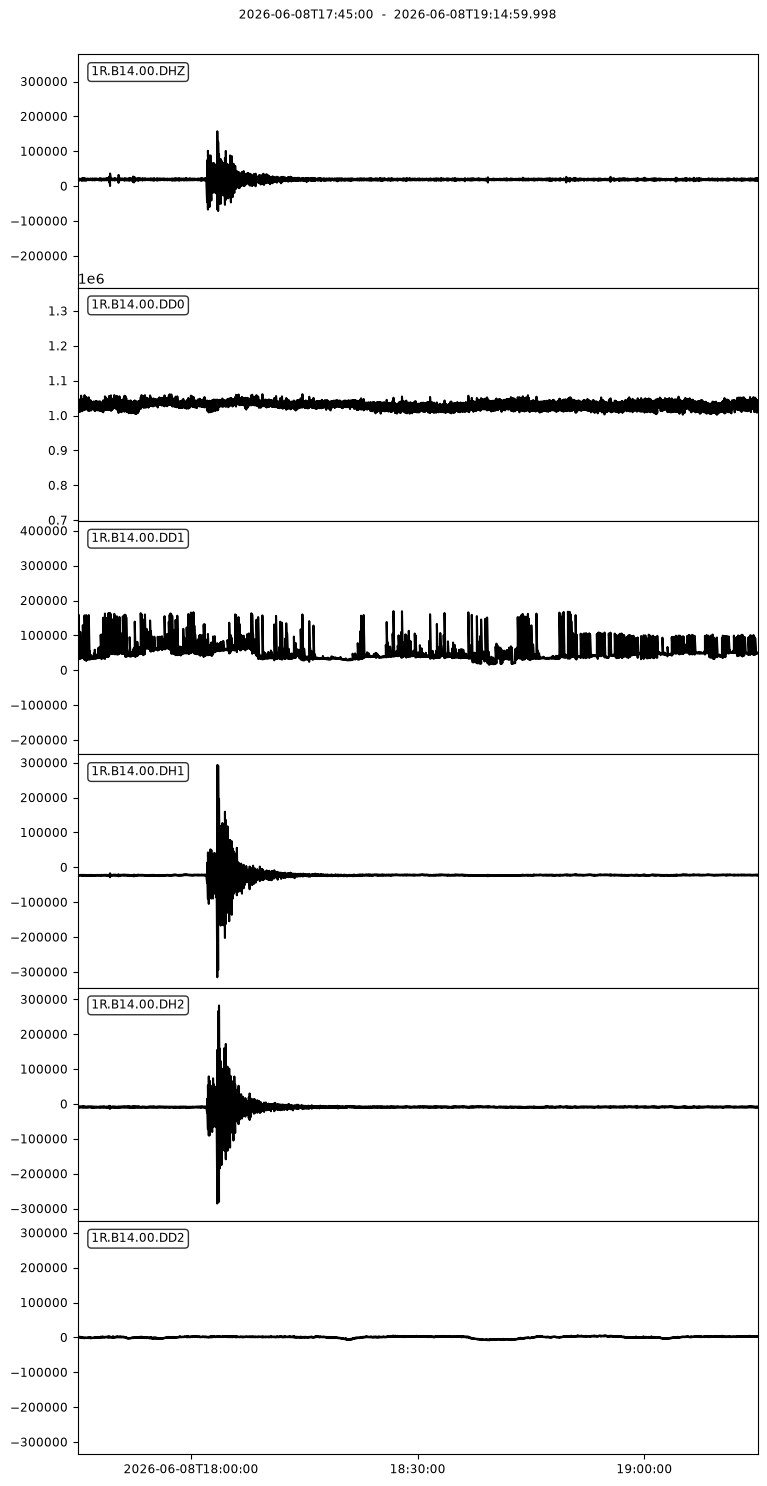

In [10]:
b14.merge()
b14 = b14.select(channel='D*')
b14.plot();